# Exploratory data analysis over the cleaned corpora

Converted from `03_eda.py`. Every question the proposal asks gets at least
one piece of evidence here:

- **Q0** Is the dataset balanced? How long are the comments?
- **Q1** Does thread context carry signal? -> parent-comment analysis (F07)
- **Q2** Do linguistic cues carry signal? -> marker rates + log-odds (F03, F08)
- **Q3** Does the subreddit carry signal? -> per-subreddit sarcasm rate (F04)
- **Q4** Does any of this survive off Reddit? -> cross-corpus comparison (F09)

Each figure gets its own section below: the function that builds it, then a
cell that calls it so the plot renders directly under that cell (`plt.show()`
has been added before each `viz.save(...)` so the figures display inline as
well as being written to `reports/eda/figures/`).

Statistics are still accumulated into the `STATS` dict and written to
`reports/eda/eda_statistics.json` at the end, exactly as in the script.


## Setup

In [28]:
from __future__ import annotations

import argparse
import json
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / ".."))
from common.paths import EDA_FIGURES as FIGURES, EDA_RESULTS, PROCESSED, ensure_dirs  # noqa: E402
from common import viz                                              # noqa: E402

import matplotlib.pyplot as plt                                     # noqa: E402

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

viz.apply_style()
STATS: dict = {}


%matplotlib inline
import matplotlib.pyplot as plt

### Marker columns & helpers used across several figures

In [29]:
MARKER_COLS = [
    ("n_exclam", "Exclamation !"),
    ("n_question", "Question ?"),
    ("n_ellipsis", "Ellipsis ..."),
    ("n_repeat_punct", "Repeated punct !!"),
    ("n_allcaps_words", "ALL-CAPS word"),
    ("n_emoji", "Emoji"),
    ("n_elongation", "Elongation (sooo)"),
    ("n_scare_quotes", "Scare quotes"),
    ("n_interjections", "Interjection (oh/wow)"),
]

RE_TOKEN = re.compile(r"[a-z][a-z']+")

### Pick the primary corpus file

In [30]:
def pick_primary(explicit: str | None) -> Path:
    if explicit:
        return Path(explicit)
    full = PROCESSED / "reddit_sarc_balanced_full.parquet"
    if full.exists():
        return full
    cands = sorted(PROCESSED.glob("reddit_sarc_balanced_*.parquet"))
    if not cands:
        raise SystemExit("No cleaned primary corpus. Run scripts/01_clean_primary.ipynb first.")
    return cands[-1]

## Load the cleaned data

Primary corpus (SARC, from `01_clean_primary*.ipynb`) and the combined
supplementary corpus (from `02_clean_supplementary.py`).

In [31]:
ensure_dirs()

pp = pick_primary(None)   # pass a path string here to override, like --primary did
print(f"[load] primary: {pp.name}")
df = pd.read_parquet(pp)
sup = pd.read_parquet(PROCESSED / "supplementary_all_clean.parquet")
print(f"       primary {len(df):,} rows | supplementary {len(sup):,} rows")

STATS["primary_source"] = pp.name
STATS["primary_rows"] = int(len(df))
STATS["supplementary_rows"] = int(len(sup))

df.head()


[load] primary: reddit_sarc_balanced_full.parquet
       primary 913,769 rows | supplementary 45,780 rows


,label,comment_clean,parent_clean,subreddit,author,score,ups,downs,ups_is_missing,downs_is_missing,...,parent_n_words,parent_n_chars,parent_is_empty,parent_jaccard,len_ratio_to_parent,had_slash_s,had_label_hashtag,had_explicit_sarcasm_word,en_score,lang_method
0,0,NC and NH.,"Yeah, I get that argument. At this point, I'd ...",politics,Trumpbart,2.0,-1.0,-1.0,True,True,...,17,80,False,0.052632,0.176471,False,False,False,1.000000,heuristic-high
1,0,You do know west teams play against west teams...,The blazers and Mavericks (The wests 5 and 6 s...,nba,Shbshb906,-4.0,-1.0,-1.0,True,True,...,25,134,False,0.032258,0.560000,False,False,False,0.900000,heuristic-high
2,0,"They were underdogs earlier today, but since G...",They're favored to win.,nfl,Creepeth,3.0,3.0,0.0,False,False,...,4,23,False,0.047619,4.500000,False,False,False,0.990278,heuristic-high
3,0,"This meme isn't funny none of the ""new york ni...",deadass don't kill my buzz,BlackPeopleTwitter,icebrotha,-8.0,-1.0,-1.0,True,True,...,5,26,False,0.000000,2.400000,False,False,False,1.000000,heuristic-high
4,0,I could use one of those tools.,Yep can confirm I saw the tool they use for th...,MaddenUltimateTeam,cush2push,6.0,-1.0,-1.0,True,True,...,19,85,False,0.083333,0.368421,False,False,False,1.000000,heuristic-high


## F01 — class balance (Q0)

Is SARC balanced? How does that compare to the supplementary corpora?

In [32]:
def f01_balance(df: pd.DataFrame, sup: pd.DataFrame) -> None:
    counts = df["label"].value_counts().sort_index()
    STATS["primary_label_counts"] = {int(k): int(v) for k, v in counts.items()}
    STATS["primary_sarcastic_rate"] = round(float(df["label"].mean()), 4)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2),
                                   gridspec_kw={"width_ratios": [1, 1.6]})

    b = ax1.bar([viz.LABEL_NAMES[i] for i in counts.index],
                counts.values / 1000,
                color=[viz.LABEL_COLORS[i] for i in counts.index],
                width=0.55)
    for bar in b:
        bar.set_path_effects([])
    viz.bar_labels(ax1, b, fmt="{:,.0f}k")
    ax1.set_ylabel("Comments (thousands)")
    ax1.set_title("SARC is balanced by construction")
    viz.subtitle(ax1, f"n = {len(df):,} after cleaning")
    ax1.set_ylim(0, counts.max() / 1000 * 1.18)
    ax1.grid(axis="x", visible=False)
    viz.despine(ax1)

    order = (sup.groupby("dataset")["label"].agg(["size", "mean"])
                .sort_values("size", ascending=False))
    STATS["supplementary_balance"] = {
        k: {"n": int(v["size"]), "sarcastic_rate": round(float(v["mean"]), 4)}
        for k, v in order.iterrows()
    }
    y = np.arange(len(order))
    ax2.barh(y, order["mean"] * 100, color=viz.C_SARC, height=0.55)
    ax2.axvline(50, color=viz.INK_MUTED, lw=1, ls="--")
    # Labels sit in a fixed right-hand column rather than at each bar end, so
    # they never collide with the balance line the bars cluster around.
    for i, (name, row) in enumerate(order.iterrows()):
        ax2.annotate(f"{row['mean']*100:.1f}%   n={int(row['size']):,}",
                     (103, i), va="center", fontsize=8.5, color=viz.INK_2,
                     annotation_clip=False)
    ax2.set_yticks(y, order.index)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel("Share of rows labelled sarcastic (%)")
    ax2.set_title("Supplementary corpora: size and balance")
    viz.subtitle(ax2, "dashed line = perfect balance")
    ax2.grid(axis="y", visible=False)
    ax2.invert_yaxis()
    viz.despine(ax2)

    plt.show()
    viz.save(fig, FIGURES / "F01_class_balance.png", "class balance")

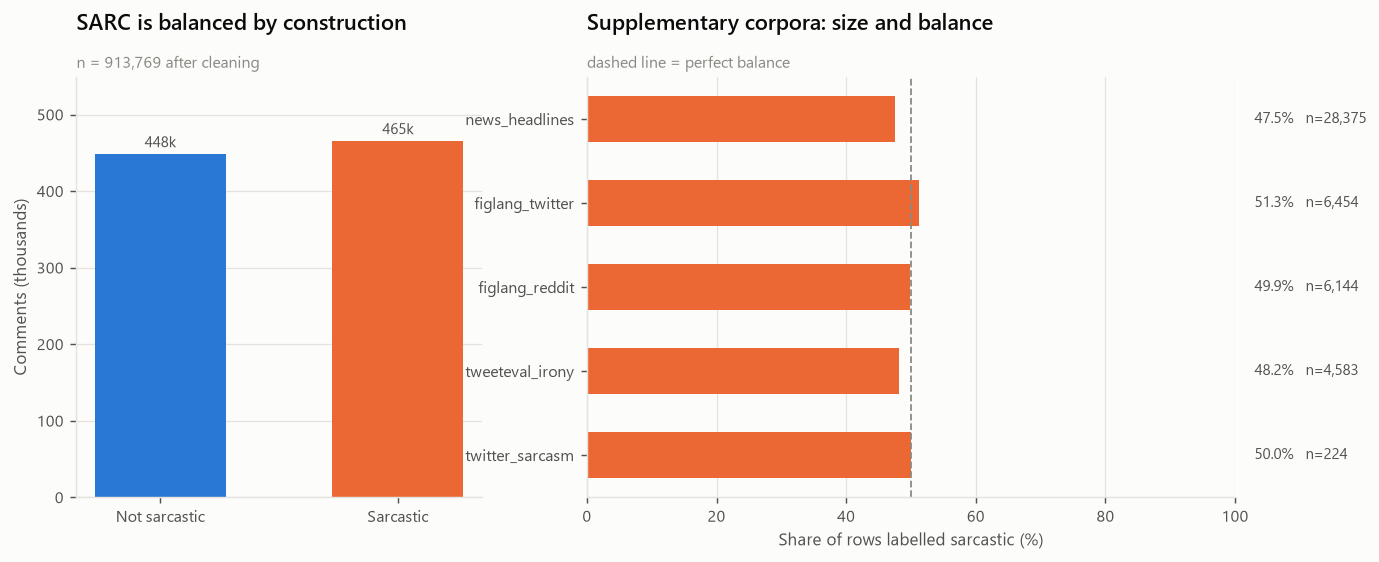

  [fig] F01_class_balance.png  — class balance


In [33]:
f01_balance(df, sup)

## F02 — comment length distribution (Q0)

How long are comments, and does length differ by class?

In [34]:
def f02_length(df: pd.DataFrame) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    bins = np.arange(0, 61, 2)
    for lab in (0, 1):
        ax1.hist(df.loc[df.label == lab, "n_words"], bins=bins, density=True,
                 histtype="step", lw=2, color=viz.LABEL_COLORS[lab],
                 label=viz.LABEL_NAMES[lab])
    ax1.set_xlabel("Words per comment")
    ax1.set_ylabel("Density")
    ax1.set_title("Length distributions are near-identical")
    med = df.groupby("label")["n_words"].median()
    mean = df.groupby("label")["n_words"].mean()
    STATS["length_words"] = {
        "median": {int(k): float(v) for k, v in med.items()},
        "mean": {int(k): round(float(v), 2) for k, v in mean.items()},
        "p90": {int(k): float(v) for k, v in
                df.groupby("label")["n_words"].quantile(0.9).items()},
    }
    viz.subtitle(ax1, f"median {med.get(1, float('nan')):.0f} vs "
                      f"{med.get(0, float('nan')):.0f} words — SARC matched the "
                      f"classes on thread, so length is not a giveaway")
    ax1.legend()
    ax1.grid(axis="x", visible=False)
    viz.despine(ax1)

    # Sarcasm rate as a function of length answers "is length a shortcut?"
    df = df.assign(_bin=pd.cut(df["n_words"], [0, 3, 5, 8, 12, 18, 25, 40, 1000],
                               labels=["1-3", "4-5", "6-8", "9-12", "13-18",
                                       "19-25", "26-40", "40+"]))
    rate = df.groupby("_bin", observed=True)["label"].agg(["mean", "size"])
    STATS["sarcasm_rate_by_length"] = {
        str(k): {"rate": round(float(v["mean"]), 4), "n": int(v["size"])}
        for k, v in rate.iterrows()
    }
    bars = ax2.bar(rate.index.astype(str), rate["mean"] * 100,
                   color=viz.C_SARC, width=0.62)
    viz.bar_labels(ax2, bars, fmt="{:.0f}%")
    ax2.axhline(50, color=viz.INK_MUTED, lw=1, ls="--")
    ax2.set_xlabel("Comment length (words)")
    ax2.set_ylabel("Sarcastic (%)")
    ax2.set_ylim(0, 100)
    ax2.set_title("The length effect is real but non-monotonic")
    viz.subtitle(ax2, "peaks mid-length; a linear length feature cannot capture this")
    ax2.grid(axis="x", visible=False)
    viz.despine(ax2)

    plt.show()
    viz.save(fig, FIGURES / "F02_length_distribution.png", "length")

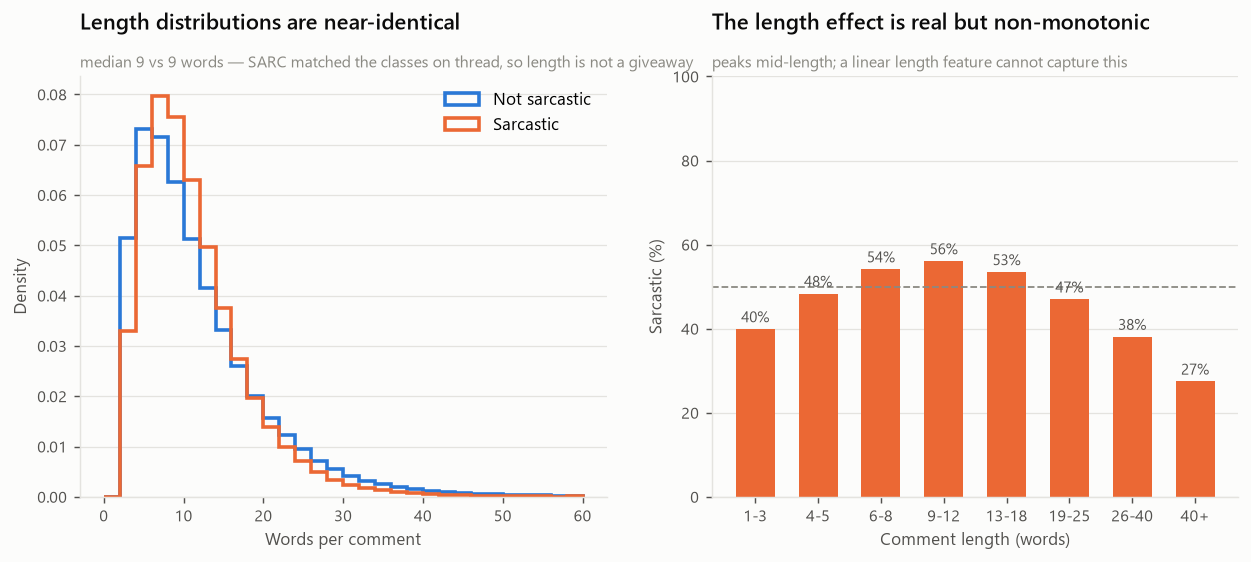

  [fig] F02_length_distribution.png  — length


In [35]:
f02_length(df)

## F03 — linguistic surface markers (Q2)

Presence rate and lift of punctuation/emoji/interjection markers by class.

In [36]:
def f03_markers(df: pd.DataFrame) -> None:
    rows = []
    for col, name in MARKER_COLS:
        pres = df[col] > 0
        r0 = float(pres[df.label == 0].mean()) * 100
        r1 = float(pres[df.label == 1].mean()) * 100
        # A marker that is essentially absent from the corpus (SARC predates
        # widespread emoji use on Reddit) makes the lift ratio pure noise.
        rare = max(r0, r1) < 0.1
        rows.append({"marker": name, "col": col, "rate_not": r0, "rate_sarc": r1,
                     "lift": float("nan") if (rare or not r0) else r1 / r0,
                     "too_rare": rare})
    m = pd.DataFrame(rows).sort_values("lift", ascending=False, na_position="last")
    STATS["marker_presence_rates_pct"] = m.round(3).to_dict("records")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6),
                                   gridspec_kw={"width_ratios": [1.5, 1]})
    y = np.arange(len(m))
    h = 0.36
    ax1.barh(y - h / 2, m["rate_not"], height=h, color=viz.C_NOT,
             label=viz.LABEL_NAMES[0])
    ax1.barh(y + h / 2, m["rate_sarc"], height=h, color=viz.C_SARC,
             label=viz.LABEL_NAMES[1])
    for i, row in enumerate(m.itertuples()):
        ax1.annotate(f"{row.rate_not:.1f}", (row.rate_not, i - h / 2), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=8, color=viz.INK_2)
        ax1.annotate(f"{row.rate_sarc:.1f}", (row.rate_sarc, i + h / 2), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=8, color=viz.INK_2)
    ax1.set_yticks(y, m["marker"])
    ax1.set_xlabel("Comments containing the marker (%)")
    ax1.set_title("Surface markers by class")
    viz.subtitle(ax1, "share of comments where the marker appears at least once")
    ax1.legend(loc="lower right")
    ax1.grid(axis="y", visible=False)
    ax1.invert_yaxis()
    viz.despine(ax1)

    ax2.barh(y, m["lift"].fillna(0), height=0.55, color=viz.C_SARC)
    ax2.axvline(1, color=viz.INK_MUTED, lw=1, ls="--")
    for i, row in enumerate(m.itertuples()):
        if np.isnan(row.lift):
            ax2.annotate("too rare to rate", (0, i), xytext=(5, 0),
                         textcoords="offset points", va="center", fontsize=8.5,
                         color=viz.INK_MUTED, style="italic")
        else:
            ax2.annotate(f"{row.lift:.2f}x", (row.lift, i), xytext=(5, 0),
                         textcoords="offset points", va="center", fontsize=8.5,
                         color=viz.INK_2)
    ax2.set_yticks(y, [""] * len(m))
    ax2.set_xlabel("Lift (sarcastic rate / non-sarcastic rate)")
    ax2.set_title("Which markers actually discriminate")
    viz.subtitle(ax2, "1.0 = no signal")
    ax2.set_xlim(0, max(2.0, float(np.nanmax(m["lift"])) * 1.3))
    ax2.grid(axis="y", visible=False)
    ax2.invert_yaxis()
    viz.despine(ax2)

    plt.show()
    viz.save(fig, FIGURES / "F03_linguistic_markers.png", "markers")

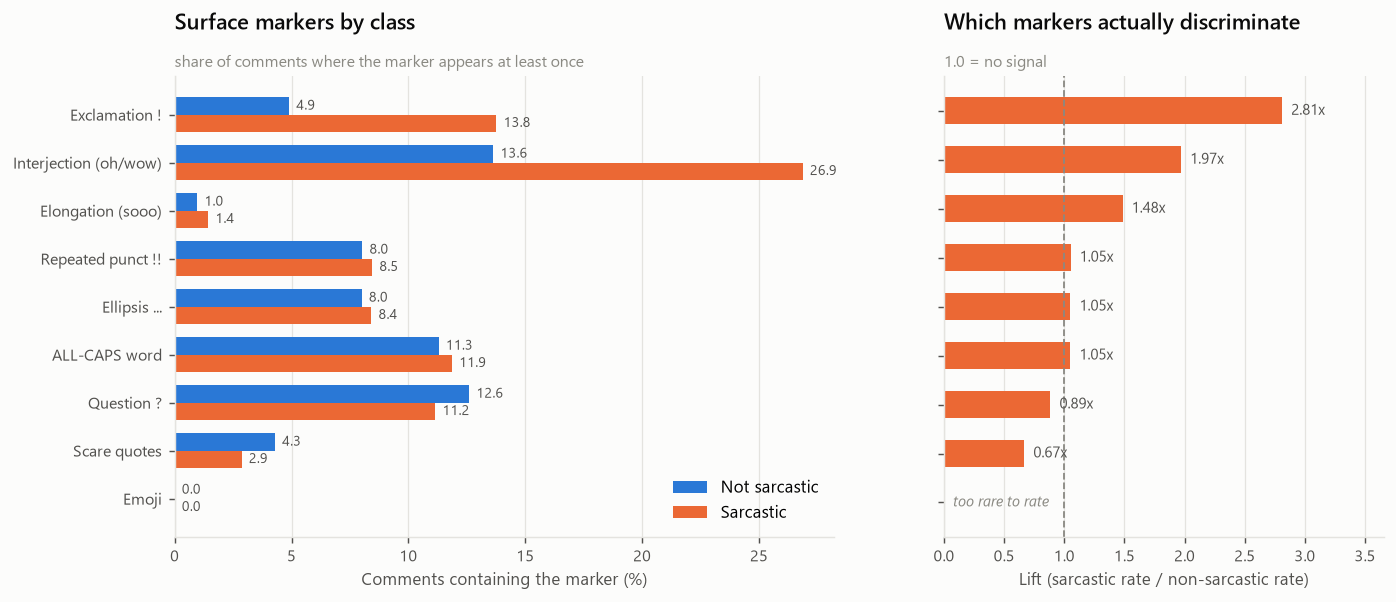

  [fig] F03_linguistic_markers.png  — markers


In [37]:
f03_markers(df)

## F08 — distinctive tokens via log-odds ratio (Q2)

Monroe et al. (2008) log-odds ratio with an informative Dirichlet prior —
the words most distinctive of each class, correcting for the stopword /
hapax problems of plain frequency or raw ratio rankings.

In [38]:
def log_odds_ratio(texts_a, texts_b, min_count=40, top=22):
    """
    Monroe et al. (2008) log-odds ratio with an informative Dirichlet prior.

    Plain frequency ranking surfaces stopwords; a raw ratio surfaces hapaxes.
    This estimator is the standard fix and is what makes the resulting word
    list defensible as "markers", which is the whole point of the project.
    """
    ca, cb = Counter(), Counter()
    for t in texts_a:
        ca.update(RE_TOKEN.findall(t))
    for t in texts_b:
        cb.update(RE_TOKEN.findall(t))

    prior = ca + cb
    vocab = [w for w in prior if prior[w] >= min_count]
    na, nb, n0 = sum(ca.values()), sum(cb.values()), sum(prior.values())
    a0 = n0 * 0.01                       # prior strength

    out = []
    for w in vocab:
        ya, yb, aw = ca[w], cb[w], prior[w] / n0 * a0
        oa = np.log((ya + aw) / (na + a0 - ya - aw))
        ob = np.log((yb + aw) / (nb + a0 - yb - aw))
        var = 1.0 / (ya + aw) + 1.0 / (yb + aw)
        out.append((w, (oa - ob) / np.sqrt(var), ya, yb))
    out.sort(key=lambda x: -x[1])
    return out[:top], out[-top:][::-1]


def f08_prepare(df: pd.DataFrame, cap: int = 200_000):
    """Cap the token counting so the EDA stays fast on the full corpus."""
    s = df.loc[df.label == 1, "comment_clean"]
    n = df.loc[df.label == 0, "comment_clean"]
    if len(s) > cap:
        s = s.sample(cap, random_state=3244)
    if len(n) > cap:
        n = n.sample(cap, random_state=3244)
    return s.str.lower().tolist(), n.str.lower().tolist()


def f08_logodds(df: pd.DataFrame) -> None:
    sarc, notsarc = f08_prepare(df)
    top_s, top_n = log_odds_ratio(sarc, notsarc)
    STATS["log_odds_top_sarcastic"] = [
        {"token": w, "z": round(float(z), 2), "n_sarc": int(a), "n_not": int(b)}
        for w, z, a, b in top_s]
    STATS["log_odds_top_not_sarcastic"] = [
        {"token": w, "z": round(float(z), 2), "n_sarc": int(a), "n_not": int(b)}
        for w, z, a, b in top_n]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6.2), sharex=False)
    for ax, data, color, title, note in [
        (ax1, top_s, viz.C_SARC, "Words that mark sarcasm",
         "agreement tokens, intensifiers and causal connectives"),
        (ax2, top_n, viz.C_NOT, "Words that mark sincerity",
         "first-person forms and hedges (my, think, pretty, actually)"),
    ]:
        words = [d[0] for d in data][::-1]
        zs = [abs(d[1]) for d in data][::-1]
        y = np.arange(len(words))
        ax.barh(y, zs, color=color, height=0.62)
        for i, (w, z) in enumerate(zip(words, zs)):
            ax.annotate(f"{z:.0f}", (z, i), xytext=(4, 0),
                        textcoords="offset points", va="center",
                        fontsize=8, color=viz.INK_2)
        ax.set_yticks(y, words)
        ax.set_xlabel("|z| of log-odds ratio (Dirichlet prior)")
        ax.set_title(title)
        viz.subtitle(ax, note)
        ax.grid(axis="y", visible=False)
        viz.despine(ax)

    plt.show()
    viz.save(fig, FIGURES / "F08_log_odds_tokens.png", "distinctive tokens")

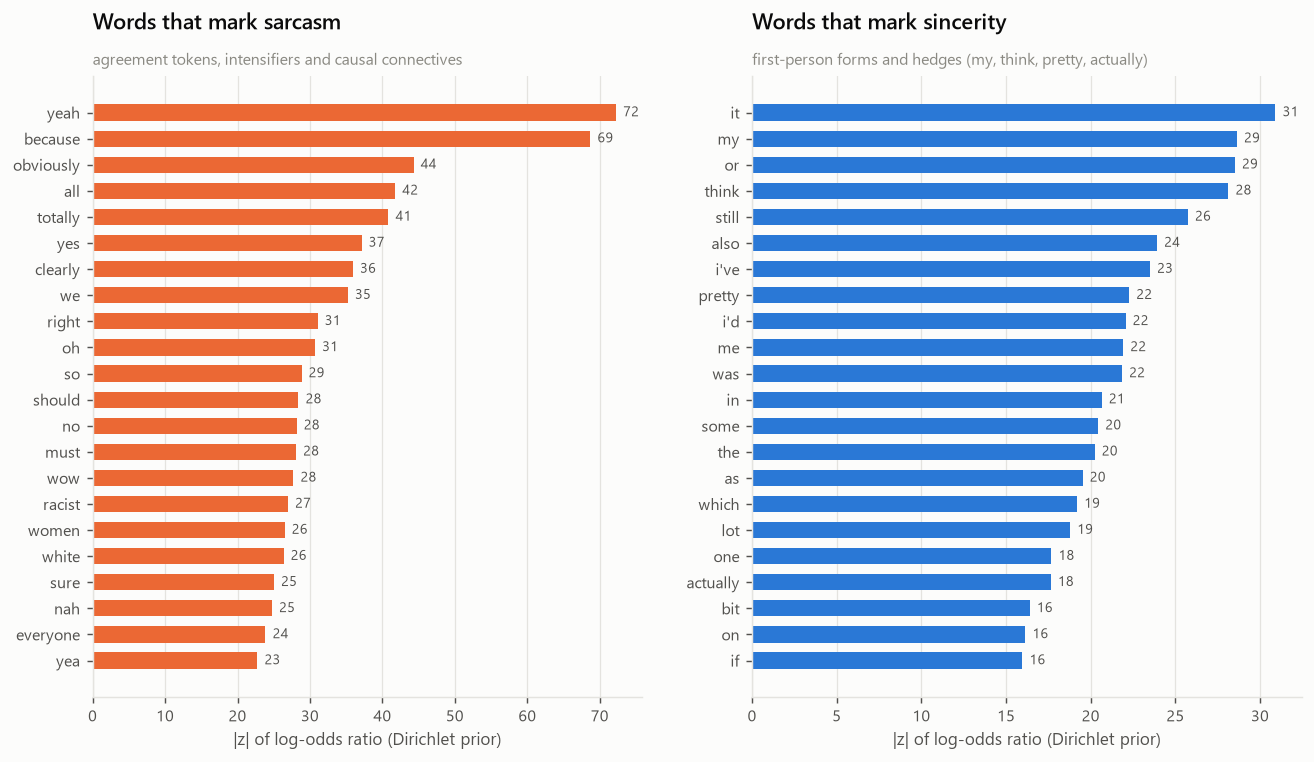

  [fig] F08_log_odds_tokens.png  — distinctive tokens


In [39]:
f08_logodds(df)

## F04 — subreddit effects (Q3)

Where is volume concentrated, and how much does sarcasm rate vary by subreddit?

In [40]:
def f04_subreddits(df: pd.DataFrame) -> None:
    g = df.groupby("subreddit")["label"].agg(["size", "mean"])
    big = g[g["size"] >= 500].sort_values("size", ascending=False)
    STATS["n_subreddits"] = int(df["subreddit"].nunique())
    STATS["subreddits_with_500plus"] = int(len(big))
    STATS["top20_subreddit_share"] = round(
        float(g.sort_values("size", ascending=False).head(20)["size"].sum() / len(df)), 4)

    top = big.head(20)
    extreme = pd.concat([big.sort_values("mean").head(10),
                         big.sort_values("mean").tail(10)])
    STATS["subreddit_sarcasm_rate_spread"] = {
        "min": round(float(big["mean"].min()), 4),
        "max": round(float(big["mean"].max()), 4),
        "std": round(float(big["mean"].std()), 4),
        "lowest": {k: round(float(v), 4) for k, v in
                   big.sort_values("mean").head(8)["mean"].items()},
        "highest": {k: round(float(v), 4) for k, v in
                    big.sort_values("mean").tail(8)["mean"].items()},
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.6))

    y = np.arange(len(top))
    ax1.barh(y, top["size"] / 1000, color=viz.SEQ[3], height=0.6)
    for i, (name, row) in enumerate(top.iterrows()):
        ax1.annotate(f"{row['size']/1000:,.1f}k", (row["size"] / 1000, i),
                     xytext=(4, 0), textcoords="offset points", va="center",
                     fontsize=8, color=viz.INK_2)
    ax1.set_yticks(y, [f"r/{s}" for s in top.index])
    ax1.set_xlabel("Comments (thousands)")
    ax1.set_title("Volume is concentrated in a few subreddits")
    viz.subtitle(ax1, f"top 20 hold {STATS['top20_subreddit_share']*100:.0f}% "
                      f"of all {len(df):,} comments")
    ax1.grid(axis="y", visible=False)
    ax1.invert_yaxis()
    viz.despine(ax1)

    y2 = np.arange(len(extreme))
    colors = [viz.C_NOT if v < 0.5 else viz.C_SARC for v in extreme["mean"]]
    ax2.barh(y2, extreme["mean"] * 100, color=colors, height=0.6)
    ax2.axvline(50, color=viz.INK_MUTED, lw=1, ls="--")
    for i, (name, row) in enumerate(extreme.iterrows()):
        ax2.annotate(f"{row['mean']*100:.0f}%", (row["mean"] * 100, i), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=8,
                     color=viz.INK_2)
    ax2.set_yticks(y2, [f"r/{s}" for s in extreme.index])
    ax2.set_xlabel("Sarcastic (%)")
    ax2.set_xlim(0, 100)
    ax2.set_title("Sarcasm rate varies sharply across subreddits")
    viz.subtitle(ax2, "10 lowest and 10 highest, among subreddits with >=500 comments")
    ax2.grid(axis="y", visible=False)
    ax2.invert_yaxis()
    viz.despine(ax2)

    plt.show()
    viz.save(fig, FIGURES / "F04_subreddits.png", "subreddits")

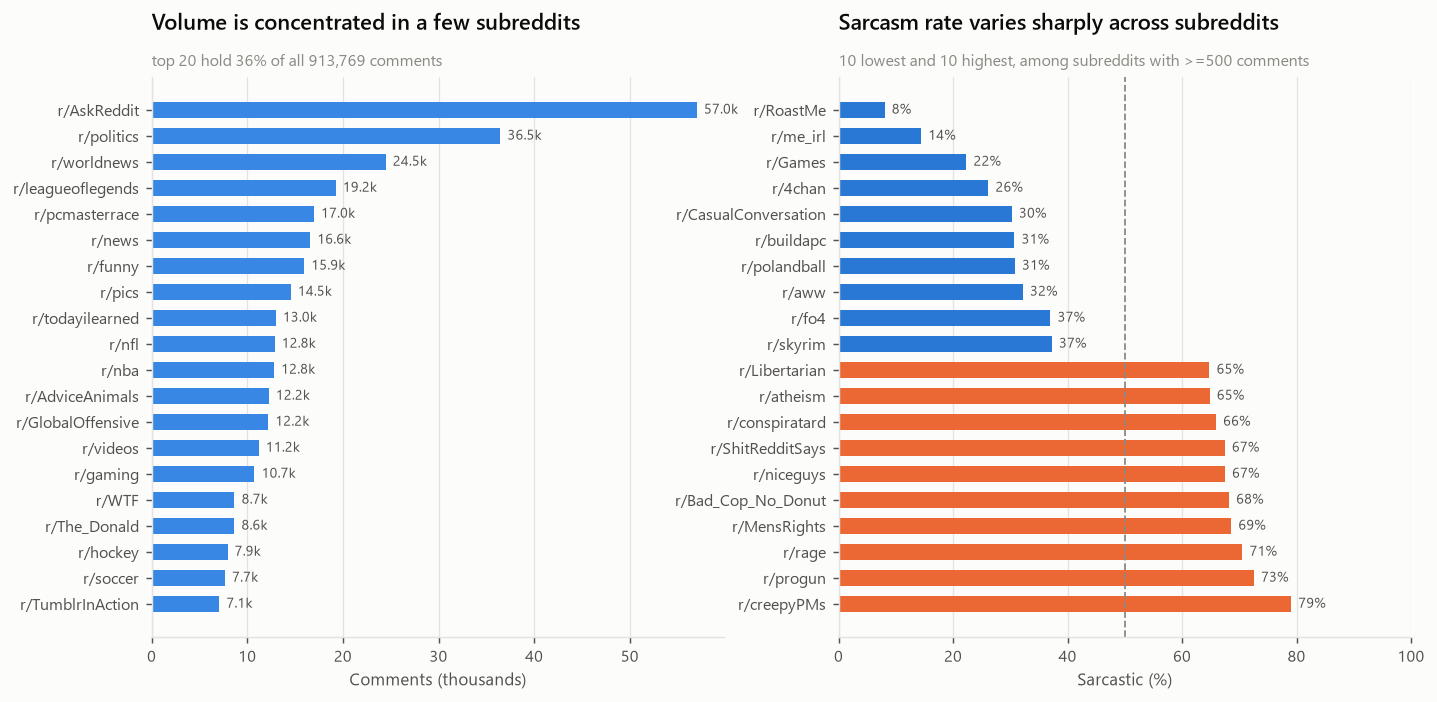

  [fig] F04_subreddits.png  — subreddits


In [41]:
f04_subreddits(df)

## F05 — temporal & score effects

Sarcasm rate by year, by hour of day, and by comment score.

In [42]:
def f05_temporal(df: pd.DataFrame) -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 3.9))

    yr = df.groupby("year")["label"].agg(["mean", "size"])
    yr = yr[yr["size"] >= 200]
    STATS["sarcasm_rate_by_year"] = {int(k): round(float(v), 4)
                                     for k, v in yr["mean"].items()}
    STATS["rows_by_year"] = {int(k): int(v) for k, v in yr["size"].items()}
    ax1.plot(yr.index.astype(int), yr["mean"] * 100, color=viz.C_SARC, marker="o")
    ax1.axhline(50, color=viz.INK_MUTED, lw=1, ls="--")
    ax1.set_title("Sarcasm rate by year")
    viz.subtitle(ax1, "balanced overall, but drifts ~11pp across the years")
    ax1.set_ylabel("Sarcastic (%)")
    ax1.set_ylim(40, 70)          # same scale as the hour panel, so "flat" reads as flat
    viz.despine(ax1)

    hr = df.groupby("hour_utc")["label"].mean() * 100
    ax2.plot(hr.index.astype(int), hr.values, color=viz.C_SARC, marker="o",
             markersize=5)
    ax2.axhline(50, color=viz.INK_MUTED, lw=1, ls="--")
    ax2.set_title("Sarcasm rate by hour (UTC)")
    viz.subtitle(ax2, "flat within 4pp — posting time carries no usable signal")
    ax2.set_xlabel("Hour of day (UTC)")
    ax2.set_ylim(40, 70)          # shared with the year panel; do not auto-zoom
    STATS["sarcasm_rate_by_hour_range_pct"] = [round(float(hr.min()), 2),
                                               round(float(hr.max()), 2)]
    viz.despine(ax2)

    bins = [-1e9, -5, -1, 0, 1, 2, 5, 10, 50, 1e9]
    names = ["<-5", "-5..-1", "0", "1", "2", "3-5", "6-10", "11-50", ">50"]
    sc = df.assign(_b=pd.cut(df["score"], bins, labels=names))
    r = sc.groupby("_b", observed=True)["label"].agg(["mean", "size"])
    STATS["sarcasm_rate_by_score"] = {str(k): {"rate": round(float(v["mean"]), 4),
                                               "n": int(v["size"])}
                                      for k, v in r.iterrows()}
    bars = ax3.bar(r.index.astype(str), r["mean"] * 100, color=viz.C_SARC, width=0.65)
    ax3.axhline(50, color=viz.INK_MUTED, lw=1, ls="--")
    ax3.set_title("Sarcasm rate by comment score")
    viz.subtitle(ax3, "unpopular comments skew sarcastic")
    ax3.set_xlabel("Reddit score (upvotes - downvotes)")
    ax3.set_ylim(0, 100)
    ax3.tick_params(axis="x", labelrotation=45)
    ax3.grid(axis="x", visible=False)
    viz.despine(ax3)

    plt.show()
    viz.save(fig, FIGURES / "F05_temporal_and_score.png", "time & score")

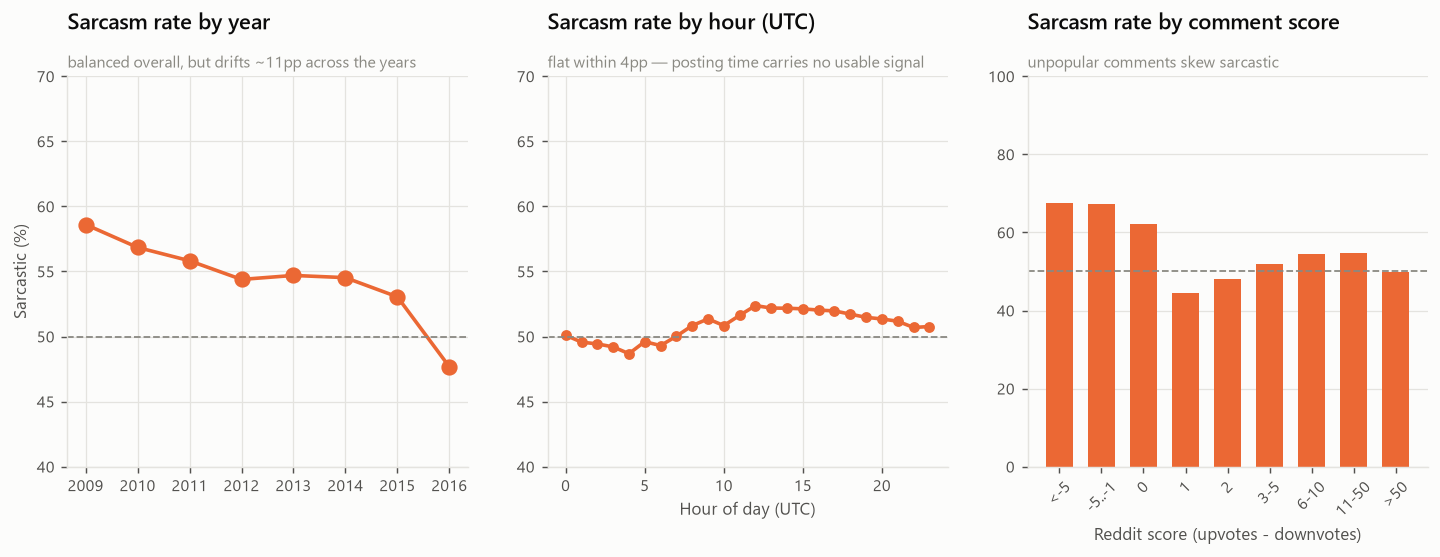

  [fig] F05_temporal_and_score.png  — time & score


In [43]:
f05_temporal(df)

## F07 — parent-comment context (Q1)

Token overlap with the parent, parent length, and reply/parent length ratio.

In [44]:
def f07_context(df: pd.DataFrame) -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 3.9))

    bins = np.linspace(0, 0.4, 41)
    for lab in (0, 1):
        ax1.hist(df.loc[df.label == lab, "parent_jaccard"], bins=bins, density=True,
                 histtype="step", lw=2, color=viz.LABEL_COLORS[lab],
                 label=viz.LABEL_NAMES[lab])
    jm = df.groupby("label")["parent_jaccard"].mean()
    STATS["parent_jaccard_mean"] = {int(k): round(float(v), 4) for k, v in jm.items()}
    ax1.set_title("Token overlap with the parent comment")
    viz.subtitle(ax1, f"mean {jm.get(1, float('nan')):.3f} vs {jm.get(0, float('nan')):.3f}")
    ax1.set_xlabel("Jaccard(comment, parent)")
    ax1.set_ylabel("Density")
    ax1.legend()
    viz.despine(ax1)

    pl = df.groupby("label")["parent_n_words"].median()
    STATS["parent_len_median"] = {int(k): float(v) for k, v in pl.items()}
    bins2 = np.arange(0, 81, 3)
    for lab in (0, 1):
        ax2.hist(df.loc[df.label == lab, "parent_n_words"], bins=bins2, density=True,
                 histtype="step", lw=2, color=viz.LABEL_COLORS[lab],
                 label=viz.LABEL_NAMES[lab])
    ax2.set_title("Parent-comment length")
    viz.subtitle(ax2, "near-identical: context length is not a shortcut")
    ax2.set_xlabel("Words in parent comment")
    ax2.legend()
    viz.despine(ax2)

    b = [0, 0.2, 0.4, 0.7, 1.0, 1.5, 2.5, 5, 1e9]
    names = ["<0.2", "0.2-0.4", "0.4-0.7", "0.7-1", "1-1.5", "1.5-2.5", "2.5-5", ">5"]
    d = df.assign(_b=pd.cut(df["len_ratio_to_parent"], b, labels=names))
    r = d.groupby("_b", observed=True)["label"].agg(["mean", "size"])
    STATS["sarcasm_rate_by_len_ratio_to_parent"] = {
        str(k): {"rate": round(float(v["mean"]), 4), "n": int(v["size"])}
        for k, v in r.iterrows()}
    bars = ax3.bar(r.index.astype(str), r["mean"] * 100, color=viz.C_SARC, width=0.65)
    ax3.axhline(50, color=viz.INK_MUTED, lw=1, ls="--")
    ax3.set_title("Reply length relative to parent")
    viz.subtitle(ax3, "flat across the whole range — no signal here")
    ax3.set_xlabel("len(reply) / len(parent)")
    ax3.set_ylabel("Sarcastic (%)")
    ax3.set_ylim(0, 100)
    ax3.tick_params(axis="x", labelrotation=45)
    ax3.grid(axis="x", visible=False)
    viz.despine(ax3)

    plt.show()
    viz.save(fig, FIGURES / "F07_parent_context.png", "context")

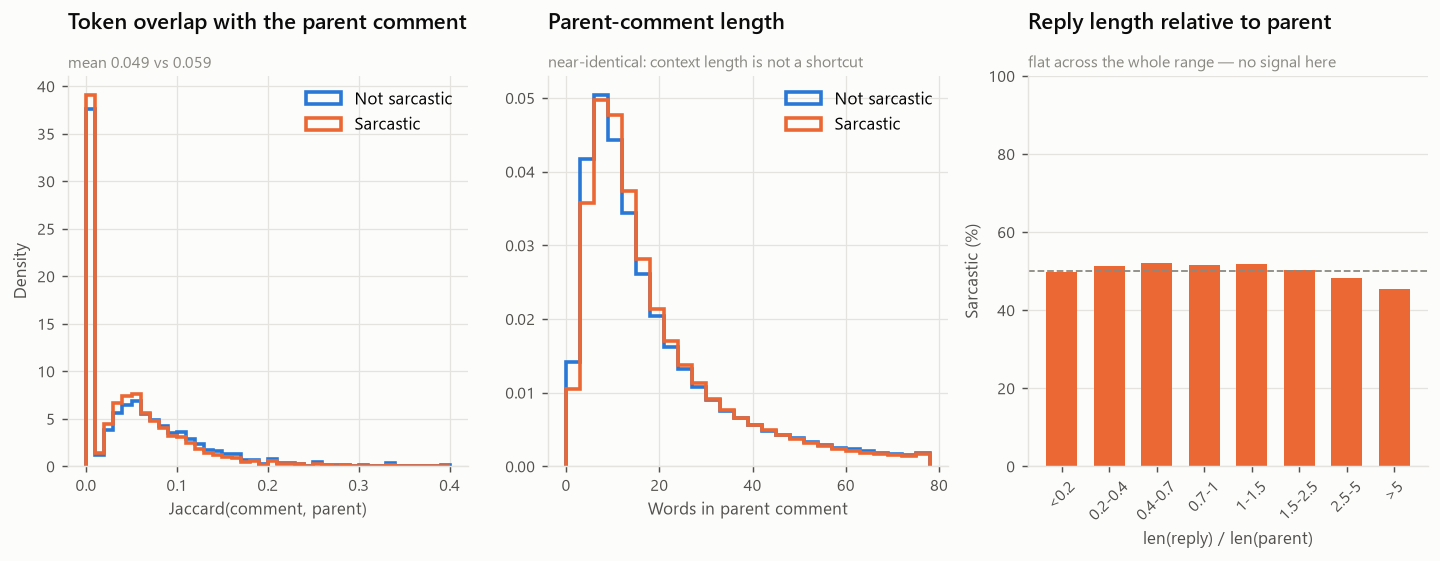

  [fig] F07_parent_context.png  — context


In [45]:
f07_context(df)

## F06 — engineered feature signal

Point-biserial correlation of every engineered feature with the label — the honest "how much is here before modelling" ranking, and a shortlist for feature selection in step 04.

In [46]:
def f06_feature_signal(df: pd.DataFrame) -> None:
    """
    Point-biserial correlation between each engineered feature and the label.

    This is the honest "how much is here before any modelling" table, and it
    doubles as a shortlist for feature selection in step 04.
    """
    num = df.select_dtypes(include=[np.number, "boolean"]).copy()
    for c in num.columns:
        if num[c].dtype == "boolean" or num[c].dtype == bool:
            num[c] = num[c].astype("float32")
    num = num.drop(columns=[c for c in ("label",) if c in num.columns])
    y = df["label"].astype(float)

    rows = []
    for c in num.columns:
        v = num[c].astype(float)
        if v.notna().sum() < 100 or v.std(skipna=True) == 0:
            continue
        r = float(np.corrcoef(v.fillna(v.median()), y)[0, 1])
        rows.append({"feature": c, "r": r, "abs_r": abs(r)})
    fr = pd.DataFrame(rows).sort_values("abs_r", ascending=False)
    STATS["feature_point_biserial_r"] = fr.drop(columns="abs_r").round(4) \
                                          .to_dict("records")

    top = fr.head(18).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.2, 6.4))
    colors = [viz.C_SARC if r > 0 else viz.C_NOT for r in top["r"]]
    y2 = np.arange(len(top))
    ax.barh(y2, top["r"], color=colors, height=0.62)
    ax.axvline(0, color=viz.INK_2, lw=1)
    for i, row in enumerate(top.itertuples()):
        off = 4 if row.r > 0 else -4
        ha = "left" if row.r > 0 else "right"
        ax.annotate(f"{row.r:+.3f}", (row.r, i), xytext=(off, 0),
                    textcoords="offset points", va="center", ha=ha,
                    fontsize=8, color=viz.INK_2)
    ax.set_yticks(y2, top["feature"])
    ax.set_xlabel("Point-biserial correlation with label (+ = sarcastic)")
    ax.set_title("No single engineered feature is close to sufficient")
    viz.subtitle(ax, "strongest |r| is well under 0.2 — the signal is distributed")
    lim = float(top["r"].abs().max()) * 1.35
    ax.set_xlim(-lim, lim)
    ax.grid(axis="y", visible=False)
    viz.despine(ax)
    plt.show()
    viz.save(fig, FIGURES / "F06_feature_correlation.png", "feature signal")

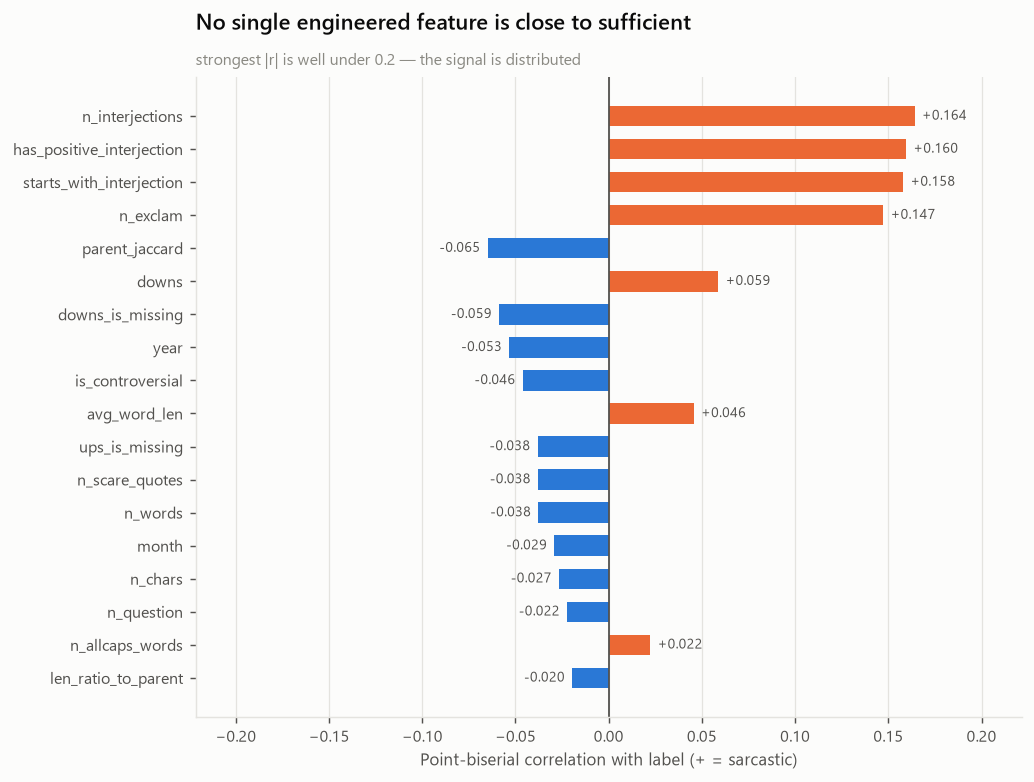

  [fig] F06_feature_correlation.png  — feature signal


In [47]:
f06_feature_signal(df)

## F09 — cross-corpus comparison (Q4)

Does anything found on Reddit survive off Reddit? Length and marker-lift comparison across all cleaned corpora.

In [48]:
def f09_cross_corpus(df: pd.DataFrame, sup: pd.DataFrame) -> None:
    prim = df[["label", "n_words"] + [c for c, _ in MARKER_COLS]].copy()
    prim["dataset"] = "reddit_sarc (primary)"
    prim["platform"] = "reddit"
    allc = pd.concat([prim, sup[["dataset", "platform", "label", "n_words"]
                                + [c for c, _ in MARKER_COLS]]], ignore_index=True)

    order = ["reddit_sarc (primary)", "figlang_reddit", "news_headlines",
             "tweeteval_irony", "figlang_twitter", "twitter_sarcasm"]
    order = [o for o in order if o in set(allc["dataset"])]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                                   gridspec_kw={"width_ratios": [1, 1.5]})

    data = [allc.loc[allc.dataset == d, "n_words"].clip(upper=80) for d in order]
    bp = ax1.boxplot(data, orientation="horizontal", showfliers=False, widths=0.55,
                     patch_artist=True, medianprops={"color": viz.INK, "lw": 1.6})
    for patch, c in zip(bp["boxes"], viz.SERIES):
        patch.set_facecolor(c)
        patch.set_alpha(0.85)
        patch.set_edgecolor(viz.SURFACE)
        patch.set_linewidth(2)
    ax1.set_yticks(range(1, len(order) + 1), order)
    ax1.set_xlabel("Words per text (clipped at 80)")
    ax1.set_title("Median text length varies ~3x across corpora")
    viz.subtitle(ax1, "a Reddit-tuned length prior will not transfer unchanged")
    ax1.grid(axis="y", visible=False)
    ax1.invert_yaxis()
    viz.despine(ax1)

    # Emoji is excluded here: it is absent from SARC and the news headlines,
    # so its "lift" would be an empty bar indistinguishable from a lift of 0.
    panel_markers = [(c, n) for c, n in MARKER_COLS if c != "n_emoji"][:6]
    rates = []
    for d in order:
        sub = allc[allc.dataset == d]
        for col, name in panel_markers:
            pres = sub[col] > 0
            r0, r1 = pres[sub.label == 0].mean(), pres[sub.label == 1].mean()
            # Same guard as F03: a marker nobody uses cannot have a lift.
            rates.append({"dataset": d, "marker": name,
                          "lift": (r1 / r0) if (r0 and max(r0, r1) >= 0.001)
                                  else np.nan})
    piv = pd.DataFrame(rates).pivot(index="marker", columns="dataset", values="lift")
    piv = piv[[c for c in order if c in piv.columns]]
    STATS["cross_corpus_marker_lift"] = piv.round(3).to_dict()

    x = np.arange(len(piv.index))
    w = 0.8 / len(piv.columns)
    for i, d in enumerate(piv.columns):
        ax2.bar(x + i * w - 0.4 + w / 2, piv[d].fillna(0), width=w * 0.88,
                color=viz.SERIES[i], label=d)
    ax2.axhline(1, color=viz.INK_MUTED, lw=1, ls="--")
    ax2.set_xticks(x, piv.index, rotation=25, ha="right")
    ax2.set_ylabel("Lift (sarcastic / not)")
    ax2.set_title("The same marker points different ways in different corpora")
    viz.subtitle(ax2, "1.0 = no signal; below 1.0 = marker predicts NOT sarcastic")
    ax2.legend(ncol=2, fontsize=8)
    ax2.grid(axis="x", visible=False)
    viz.despine(ax2)

    plt.show()
    viz.save(fig, FIGURES / "F09_cross_corpus.png", "cross-corpus")

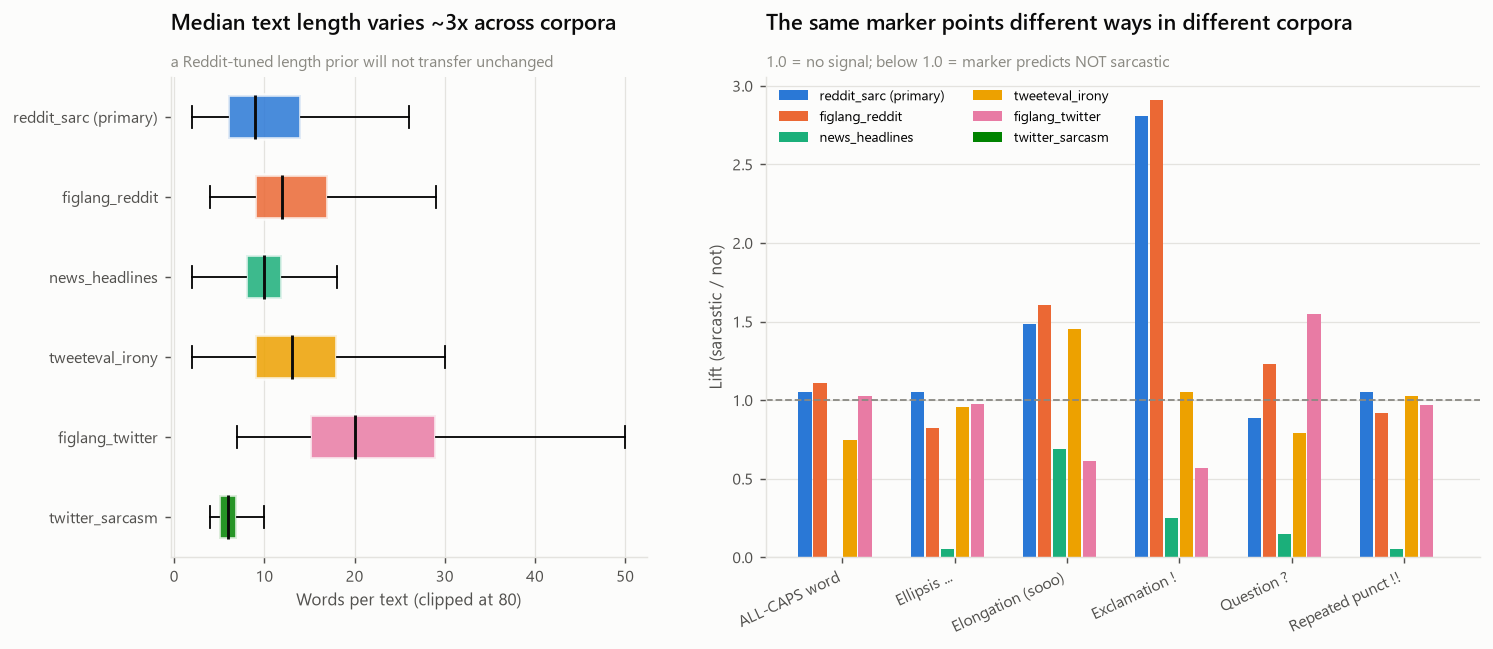

  [fig] F09_cross_corpus.png  — cross-corpus


In [49]:
f09_cross_corpus(df, sup)

## F10 — context availability in FigLang

How much multi-turn context does FigLang provide, compared to SARC's single parent turn?

In [50]:
def f10_context_availability(sup: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7.6, 4.0))
    fl = sup[sup["dataset"].str.startswith("figlang")]
    if fl.empty:
        plt.close(fig)
        return
    g = fl.groupby(["dataset", "label"])["context_n_words"].median().unstack()
    STATS["figlang_context_median_words"] = g.round(1).to_dict()
    x = np.arange(len(g))
    w = 0.34
    b0 = ax.bar(x - w / 2, g[0], width=w, color=viz.C_NOT, label=viz.LABEL_NAMES[0])
    b1 = ax.bar(x + w / 2, g[1], width=w, color=viz.C_SARC, label=viz.LABEL_NAMES[1])
    viz.bar_labels(ax, b0, fmt="{:.0f}")
    viz.bar_labels(ax, b1, fmt="{:.0f}")
    ax.set_xticks(x, g.index)
    ax.set_ylabel("Median words of context available")
    ax.set_title("FigLang gives multi-turn context for the Q1 ablation")
    viz.subtitle(ax, "SARC only ever supplies one parent turn")
    ax.legend()
    ax.grid(axis="x", visible=False)
    viz.despine(ax)
    plt.show()
    viz.save(fig, FIGURES / "F10_context_availability.png", "context availability")

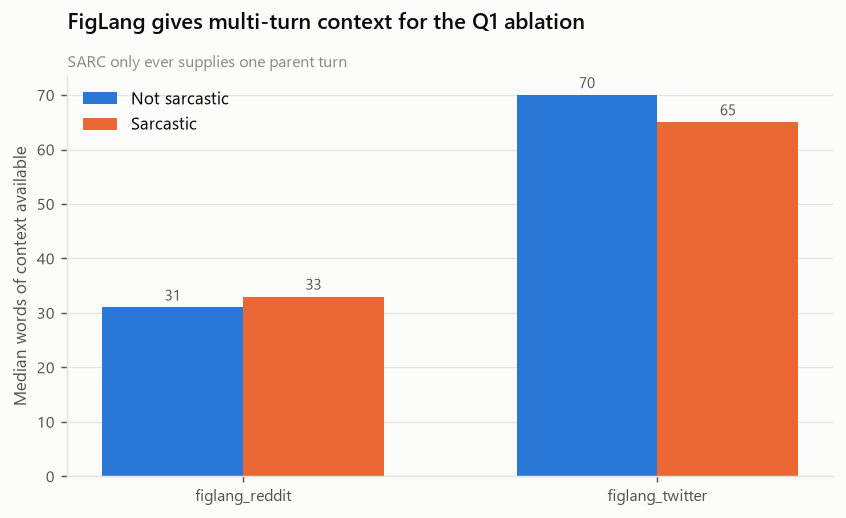

  [fig] F10_context_availability.png  — context availability


In [51]:
f10_context_availability(sup)

## Save statistics

Write every number collected in `STATS` to `eda_statistics.json`, and confirm how many figures were produced.

In [52]:
out = EDA_RESULTS / "eda_statistics.json"
out.write_text(json.dumps(STATS, indent=2, ensure_ascii=False, default=str),
               encoding="utf-8")
print(f"[save] {out}")
print(f"[save] {len(list(FIGURES.glob('*.png')))} figures in {FIGURES}")


[save] C:\Users\USER\OneDrive\Documents\CS3244\cs3244_group1\results\eda\eda_statistics.json
[save] 10 figures in C:\Users\USER\OneDrive\Documents\CS3244\cs3244_group1\figures\eda
